### import packages


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as npr
from scipy.stats import norm

import pandas as pd

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # one level up
from functions import * 

In [3]:
n = 5000
k_list =  list(range(100, 500, 10)) 
num_k = len(k_list)
dim = 2

delta = 2

B = 50

p = 0.025
z = norm.ppf(1 - p)

In [4]:
alpha= 1.0
beta = 0.5

## generating data

In [5]:
data_set = np.zeros([n, dim])

# take symmetric copula to be gumbel with delta = 2
c = lambda u, v: gumbel(u, v, delta=delta)
asym_c = asymmetrization(c=c, a=alpha, b=beta)
data_set[:, :] = sampling(c=asym_c, n=n)


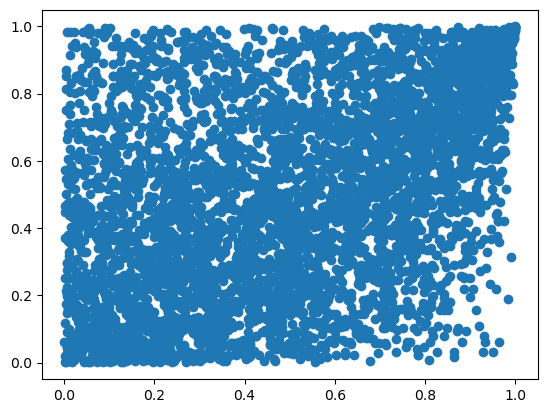

In [6]:
# plot data
plt.scatter(data_set[:, 0], data_set[:, 1])

In [7]:
with open('asymmetrized_gumbel_data.npy', 'wb') as f:
    np.save(f, data_set)




In [8]:
with open('asymmetrized_gumbel_data.npy', 'rb') as f:
    data_set = np.load(f)

# take $\alpha=1., \beta=0.5$ data

In [9]:
delta_table = np.zeros([num_k])
delta_boot_table = np.zeros([num_k, B])

xs, ys = data_set[:, 0], data_set[:, 1]

for i in range(num_k):
    print("{}-th k".format(i+1))
    k = k_list[i]
    etaXY = eta(xs, ys, k)
    etaYX = eta(ys, xs, k)
    delta_table[i] = etaXY - etaYX
    for b in range(B):
        ms = npr.exponential(size=n)
        eta_boot_XY = eta_boot(xs, ys, ms, k)
        eta_boot_YX = eta_boot(ys, xs, ms, k)
        delta_boot_table[i, b] = eta_boot_XY-eta_boot_YX



1-th k
2-th k
3-th k
4-th k
5-th k
6-th k
7-th k
8-th k
9-th k
10-th k
11-th k
12-th k
13-th k
14-th k
15-th k
16-th k
17-th k
18-th k
19-th k
20-th k
21-th k
22-th k
23-th k
24-th k
25-th k
26-th k
27-th k
28-th k
29-th k
30-th k
31-th k
32-th k
33-th k
34-th k
35-th k
36-th k
37-th k
38-th k
39-th k
40-th k


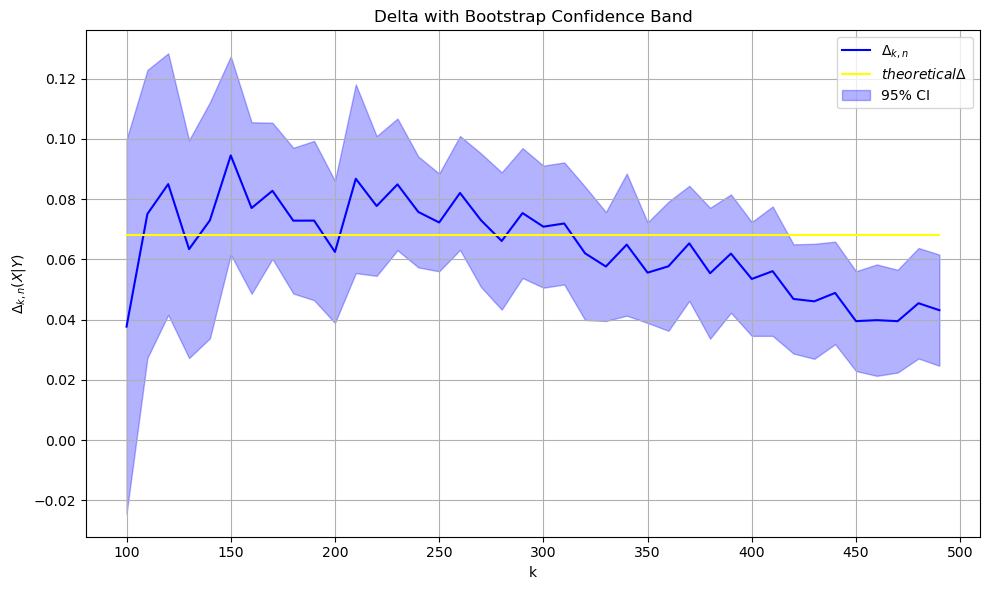

In [12]:
sqrt_k = np.sqrt(k_list)[:, None]                        # shape (num_k, 1)
T_kb = sqrt_k * (delta_boot_table - delta_table[:, None])  # shape (num_k, B)

S_k = np.std(T_kb, axis=1, ddof=1)  # shape (num_k,)
lower = delta_table - S_k * z / np.sqrt(k_list)
upper = delta_table + S_k * z / np.sqrt(k_list)
# Plot delta_table with shaded confidence band
plt.figure(figsize=(10, 6))
plt.plot(k_list, delta_table, label=r'$\Delta_{k,n}$', color='blue')
plt.plot(k_list, 0.068062 * np.ones_like(k_list) , label=r'$theoretical \Delta$', color='yellow')                        # maximum value
plt.fill_between(k_list, lower, upper, color='blue', alpha=0.3, label='95% CI')
plt.xlabel('k')
plt.ylabel(r'$\Delta_{k,n}(X|Y)$')
plt.title('Delta with Bootstrap Confidence Band')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
